# SHAP Explainability Analysis — Best Model

**Author:** John  
**Task:** M5.T4 — Apply SHAP values to best model for explainability analysis

This notebook:
1. Loads the tuned XGBoost model (best params from `best_xgboost_params.csv`)
2. Computes SHAP values for all four ESG targets
3. Produces summary plots, bar plots, waterfall plots, and dependence plots
4. Identifies the top features driving ESG score predictions per pillar
5. Analyzes SHAP values across industries to explain performance differences

**Requires:** `data/finbert_features/merged_features_labels.csv` and `data/finbert_features/best_xgboost_params.csv`

---
## Step 1 — Imports & Configuration

In [ ]:
%pip install shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

try:
    import shap
    HAS_SHAP = True
    print("SHAP loaded successfully.")
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed. Run: pip install shap")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed.")

MERGED_PATH  = r"C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\merged_features_labels.csv"
PARAMS_PATH  = r"C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\best_xgboost_params.csv"
OUTPUT_DIR   = r"C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\\"

TARGETS = ['total_score', 'environment_score', 'social_score', 'governance_score']
PILLAR_COLORS = {
    'total_score':       '#e67e22',
    'environment_score': '#2ecc71',
    'social_score':      '#3498db',
    'governance_score':  '#9b59b6'
}

print("Configuration complete.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ----- ---------------------------------- 5.5/39.2 MB 31.7 MB/s eta 0:00:02
   --------------- ------------------------ 15.2/39.2 MB 36.6 MB/s eta 0:00:01
   ------------------------ --------------- 24.1/39.2 MB 37.9 MB/s eta 0:00:01
   --------------------------------- ------ 32.5/39.2 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 38.8 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 35.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 25.4 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [tqdm]
   ----- --------------------------

---
## Step 2 — Load Data & Best Parameters

In [ ]:
if 'engineered_df' in dir() and len(engineered_df) > 0:
    df = engineered_df.copy()
    print(f"Using in-memory engineered_df: {df.shape}")
elif os.path.exists(MERGED_PATH):
    df = pd.read_csv(MERGED_PATH)
    df['ticker'] = df['ticker'].str.upper()
    print(f"Loaded merged CSV: {df.shape}")
else:
    raise FileNotFoundError("merged_features_labels.csv not found.")

if os.path.exists(PARAMS_PATH):
    params_df = pd.read_csv(PARAMS_PATH, index_col=0)
    print(f"\nLoaded best params for targets: {list(params_df.index)}")
    print(params_df.round(4).to_string())
    HAS_BEST_PARAMS = True
else:
    print("best_xgboost_params.csv not found — using default tuned params.")
    HAS_BEST_PARAMS = False

EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade',
           'environment_grade', 'social_grade', 'governance_grade',
           'environment_level', 'social_level', 'governance_level',
           'total_level', 'name', 'currency', 'exchange',
           'last_processing_date', 'cik']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols].fillna(0)
print(f"\nFeature matrix: {X.shape}")

Loaded merged CSV: (332, 83)

Loaded best params for targets: ['total', 'environment', 'social', 'governance']
             colsample_bytree  learning_rate  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample
total                  0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
environment            0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
social                 0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
governance             0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022

Feature matrix: (332, 76)


---
## Step 3 — Train Tuned XGBoost Models

Train one XGBoost model per ESG target using the best hyperparameters
found in `hyperparameter_tuning.ipynb`.

In [3]:
def get_best_params(target, params_df, has_params):
    """Get best params for a target, with safe type conversion."""
    defaults = dict(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=5, reg_alpha=1, min_child_weight=1
    )
    if not has_params or target not in params_df.index:
        return defaults
    row = params_df.loc[target].to_dict()
    for int_param in ['n_estimators', 'max_depth', 'min_child_weight']:
        if int_param in row:
            row[int_param] = int(float(row[int_param]))
    return row


trained_models = {}
split_data     = {}

for target in TARGETS:
    if target not in df.columns:
        continue

    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    params = get_best_params(target, params_df if HAS_BEST_PARAMS else None, HAS_BEST_PARAMS)

    model = XGBRegressor(**params, random_state=42, verbosity=0)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    r2  = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)

    trained_models[target] = model
    split_data[target]     = {'X_tr': X_tr, 'X_te': X_te, 'y_tr': y_tr, 'y_te': y_te}

    print(f"{target:<25}  Test R²={r2:+.4f}  MAE={mae:.2f}")

print("\nAll models trained.")

total_score                Test R²=-0.2294  MAE=173.93
environment_score          Test R²=-0.0490  MAE=111.38
social_score               Test R²=-0.1895  MAE=42.77
governance_score           Test R²=-0.2843  MAE=36.78

All models trained.


---
## Step 4 — Compute SHAP Values

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score
for each prediction. Positive SHAP = feature pushes prediction higher;
negative SHAP = feature pushes prediction lower.

In [4]:
if not HAS_SHAP:
    print("SHAP not installed. Run: pip install shap")
else:
    shap_values  = {}
    explainers   = {}

    for target in TARGETS:
        if target not in trained_models:
            continue
        print(f"Computing SHAP values for {target}...")
        model  = trained_models[target]
        X_te   = split_data[target]['X_te']

        explainer = shap.TreeExplainer(model)
        sv        = explainer.shap_values(X_te)

        shap_values[target] = sv
        explainers[target]  = explainer
        print(f"  Done — SHAP matrix shape: {sv.shape}")

    print("\nAll SHAP values computed.")

Computing SHAP values for total_score...
  Done — SHAP matrix shape: (67, 76)
Computing SHAP values for environment_score...
  Done — SHAP matrix shape: (67, 76)
Computing SHAP values for social_score...
  Done — SHAP matrix shape: (67, 76)
Computing SHAP values for governance_score...
  Done — SHAP matrix shape: (67, 76)

All SHAP values computed.


---
## Step 5 — SHAP Summary Plots

Summary plots show feature importance (x-axis = mean |SHAP|) and direction
(color = feature value: red=high, blue=low). One plot per ESG target.


SHAP Summary Plot — Total Score


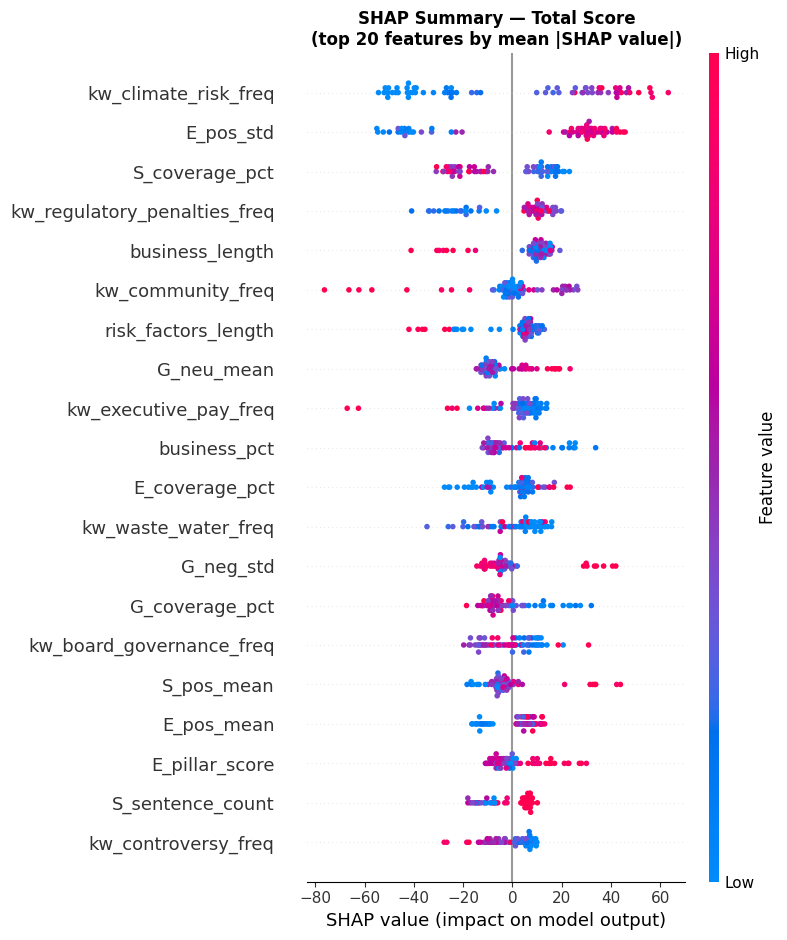

  Saved: shap_summary_total_score.png

SHAP Summary Plot — Environment Score


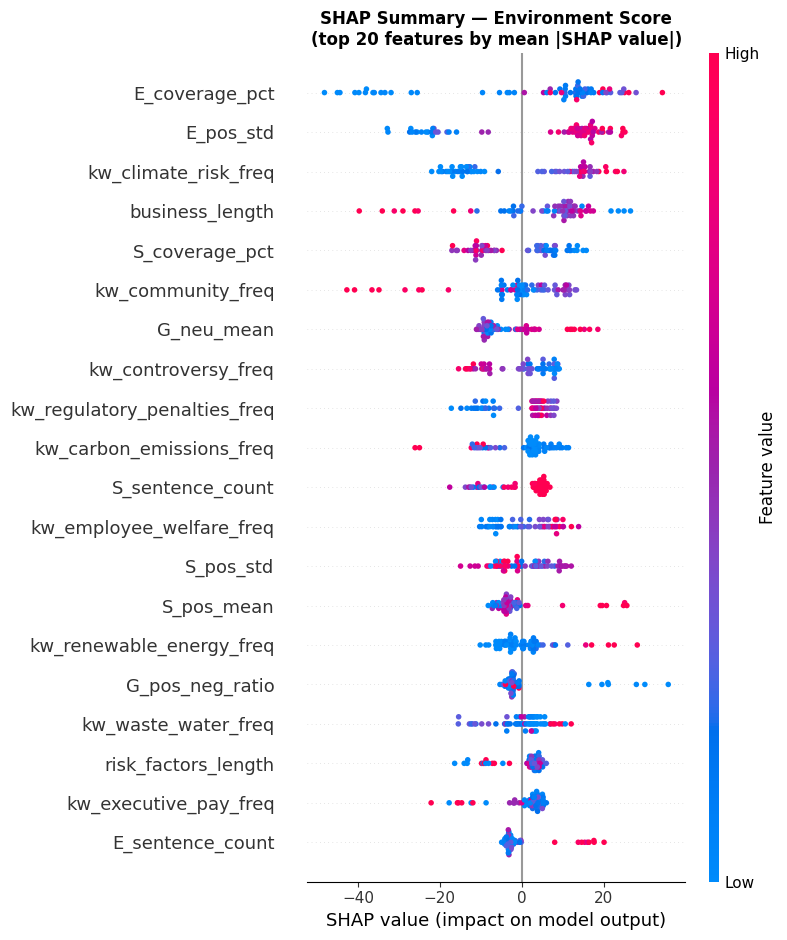

  Saved: shap_summary_environment_score.png

SHAP Summary Plot — Social Score


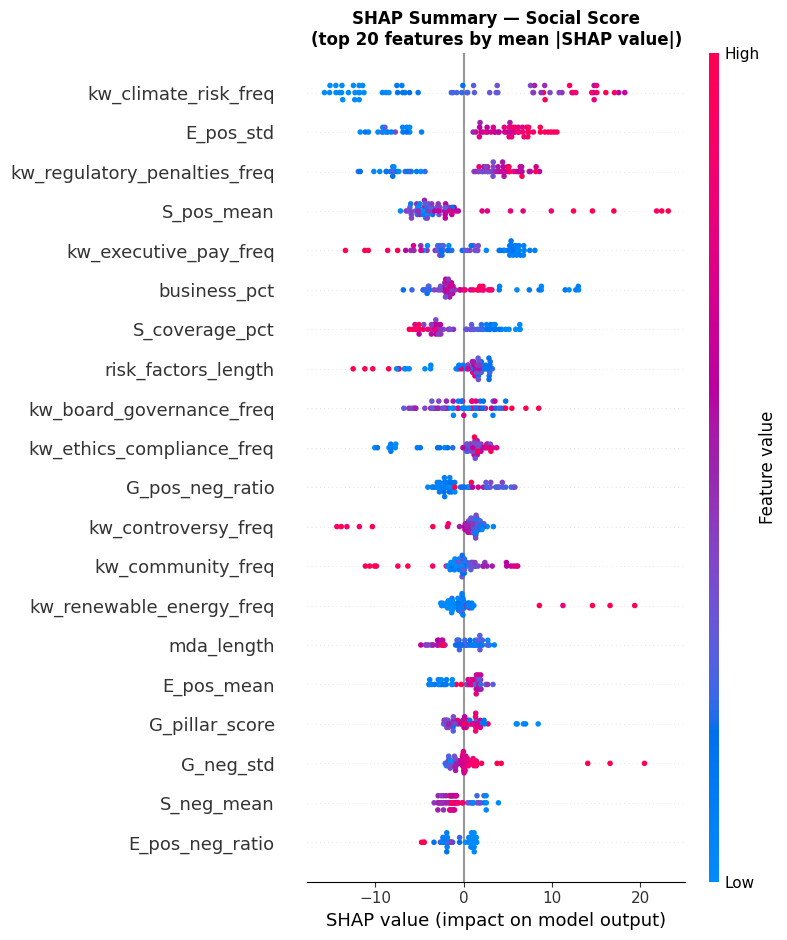

  Saved: shap_summary_social_score.png

SHAP Summary Plot — Governance Score


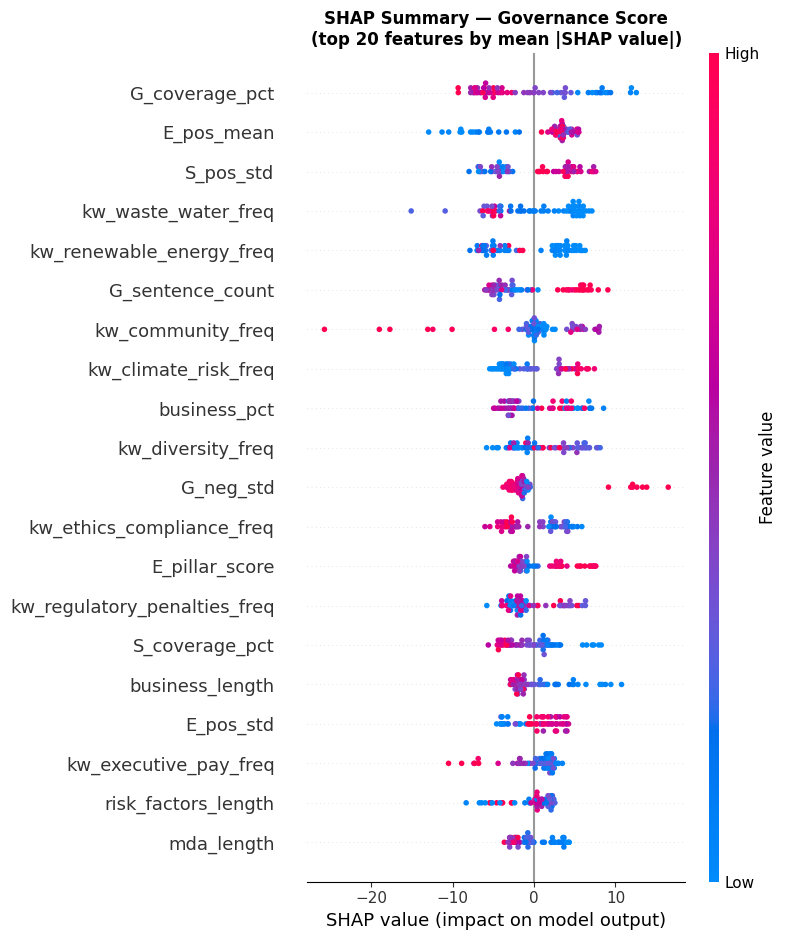

  Saved: shap_summary_governance_score.png


In [5]:
if HAS_SHAP and shap_values:
    for target in TARGETS:
        if target not in shap_values:
            continue
        color = PILLAR_COLORS.get(target, '#3498db')
        print(f"\nSHAP Summary Plot — {target.replace('_score','').title()} Score")
        plt.figure()
        shap.summary_plot(
            shap_values[target],
            split_data[target]['X_te'],
            feature_names=feature_cols,
            max_display=20,
            show=False
        )
        plt.title(
            f'SHAP Summary — {target.replace("_score","").title()} Score\n'
            f'(top 20 features by mean |SHAP value|)',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR + f'shap_summary_{target}.png',
            dpi=150, bbox_inches='tight'
        )
        plt.show()
        print(f"  Saved: shap_summary_{target}.png")

---
## Step 6 — SHAP Bar Plots (Mean Absolute SHAP)

Bar plots show the average magnitude of each feature's impact across all
predictions — a clean global feature importance ranking.

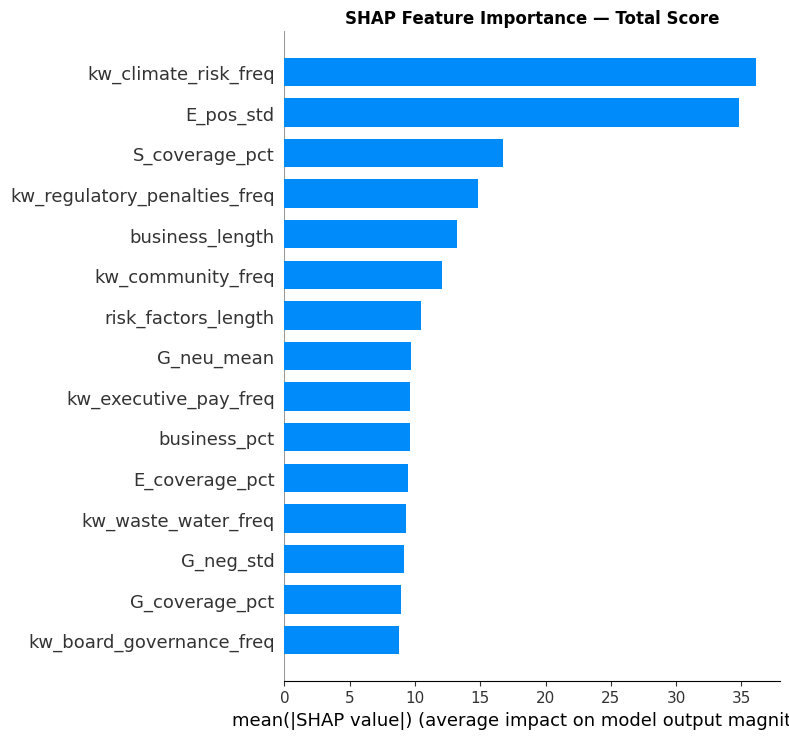

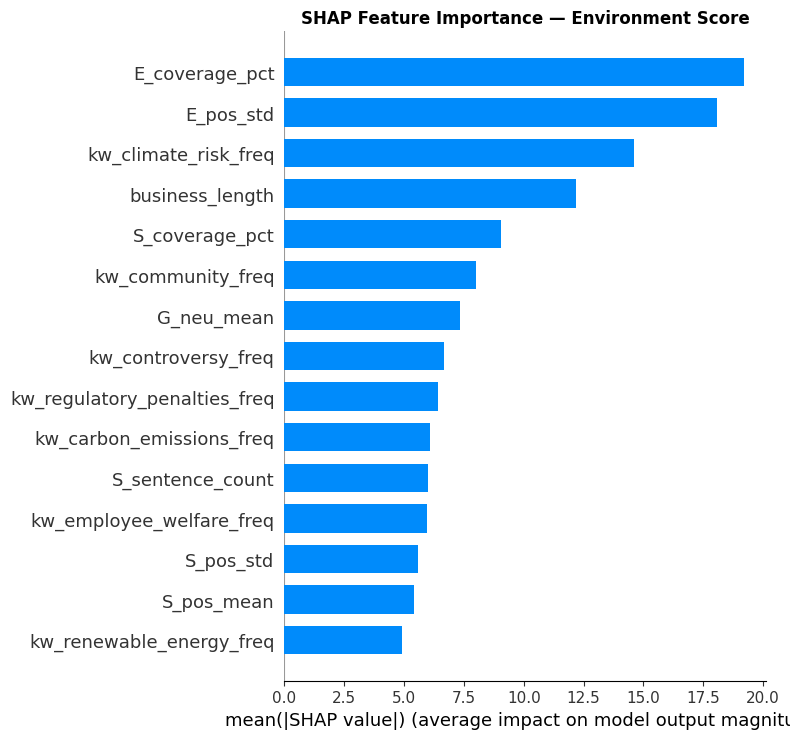

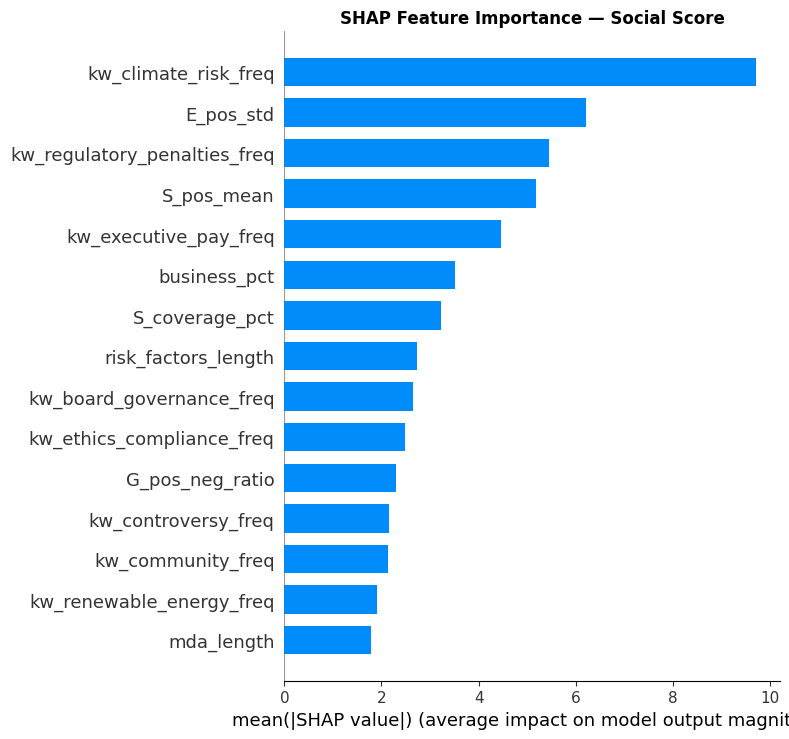

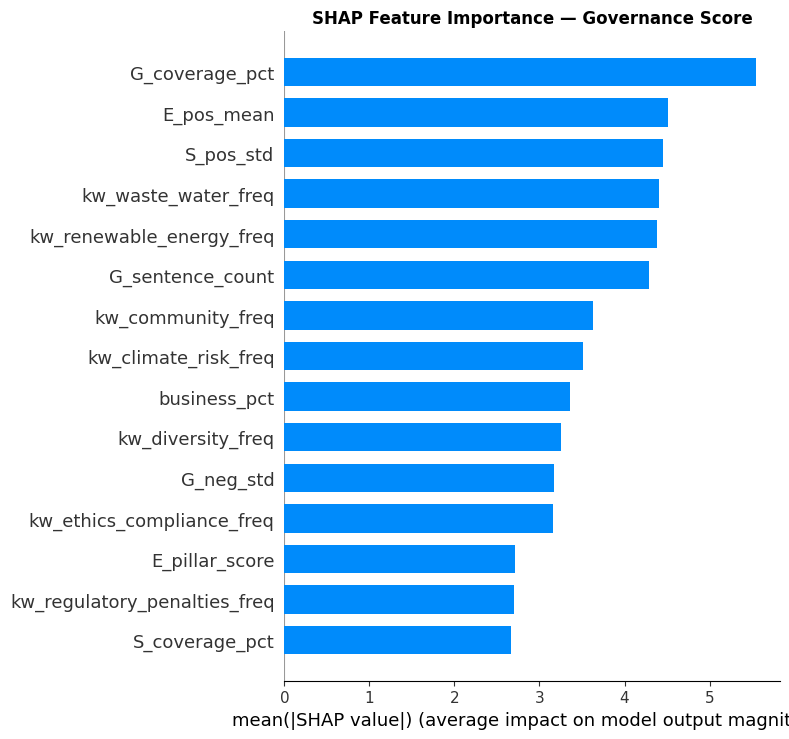

In [6]:
if HAS_SHAP and shap_values:
    for target in TARGETS:
        if target not in shap_values:
            continue
        shap.summary_plot(
            shap_values[target],
            split_data[target]['X_te'],
            feature_names=feature_cols,
            plot_type='bar',
            max_display=15,
            show=False
        )
        plt.title(
            f'SHAP Feature Importance — {target.replace("_score","").title()} Score',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR + f'shap_bar_{target}.png',
            dpi=150, bbox_inches='tight'
        )
        plt.show()

---
## Step 7 — Cross-Pillar Feature Importance Comparison

Compare which features matter most across all four ESG targets side by side.
This reveals which features are universally important vs. pillar-specific.

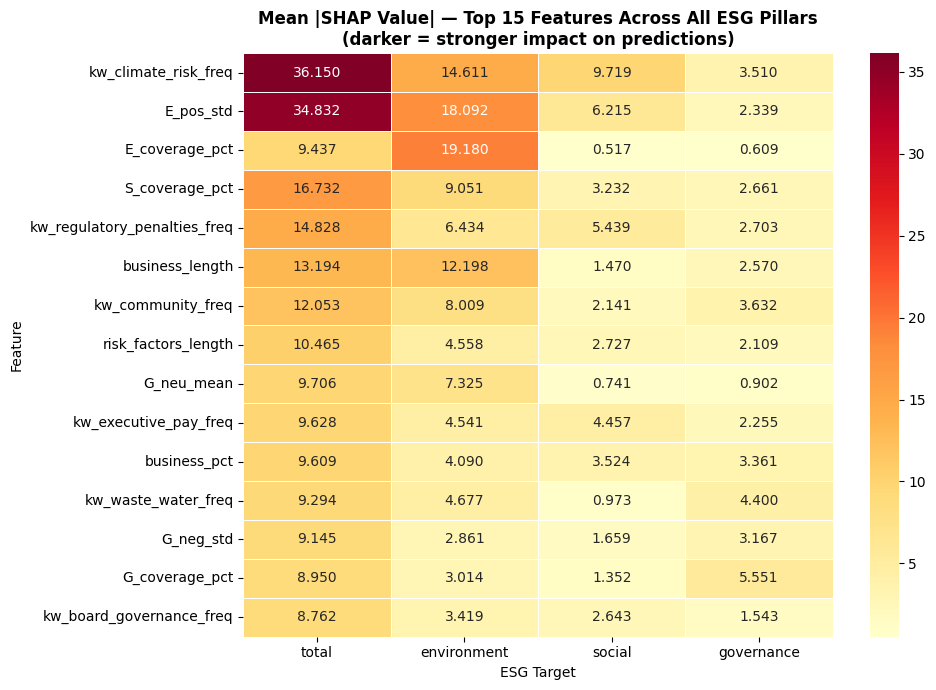

Top 15 features by max SHAP importance across any pillar:
                                  total  environment  social  governance
kw_climate_risk_freq          36.149899    14.611000  9.7191      3.5100
E_pos_std                     34.832199    18.091900  6.2151      2.3390
E_coverage_pct                 9.437000    19.180401  0.5165      0.6092
S_coverage_pct                16.731600     9.050700  3.2321      2.6611
kw_regulatory_penalties_freq  14.828400     6.433700  5.4390      2.7031
business_length               13.193600    12.198100  1.4703      2.5702
kw_community_freq             12.053300     8.009100  2.1410      3.6319
risk_factors_length           10.465400     4.558100  2.7273      2.1094
G_neu_mean                     9.705700     7.325300  0.7412      0.9018
kw_executive_pay_freq          9.628500     4.541000  4.4566      2.2553
business_pct                   9.608600     4.090300  3.5237      3.3612
kw_waste_water_freq            9.293800     4.676700  0.9730      

In [ ]:
if HAS_SHAP and shap_values:
    importance_dict = {}
    for target in TARGETS:
        if target not in shap_values:
            continue
        mean_abs = np.abs(shap_values[target]).mean(axis=0)
        importance_dict[target.replace('_score','')] = mean_abs

    importance_df = pd.DataFrame(importance_dict, index=feature_cols)

    top_features = importance_df.max(axis=1).sort_values(ascending=False).head(15).index
    top_df = importance_df.loc[top_features]

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        top_df, annot=True, fmt='.3f', cmap='YlOrRd',
        linewidths=0.5, ax=ax
    )
    ax.set_title(
        'Mean |SHAP Value| — Top 15 Features Across All ESG Pillars\n'
        '(darker = stronger impact on predictions)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('ESG Target')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'shap_cross_pillar_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 15 features by max SHAP importance across any pillar:")
    print(top_df.round(4).to_string())

    importance_df.to_csv(OUTPUT_DIR + 'shap_feature_importance_all_targets.csv')
    print(f"\nFull importance table saved to shap_feature_importance_all_targets.csv")

---
## Step 8 — SHAP Waterfall Plots

Waterfall plots explain individual predictions — showing exactly how each
feature pushed a specific company's predicted score up or down from the baseline.

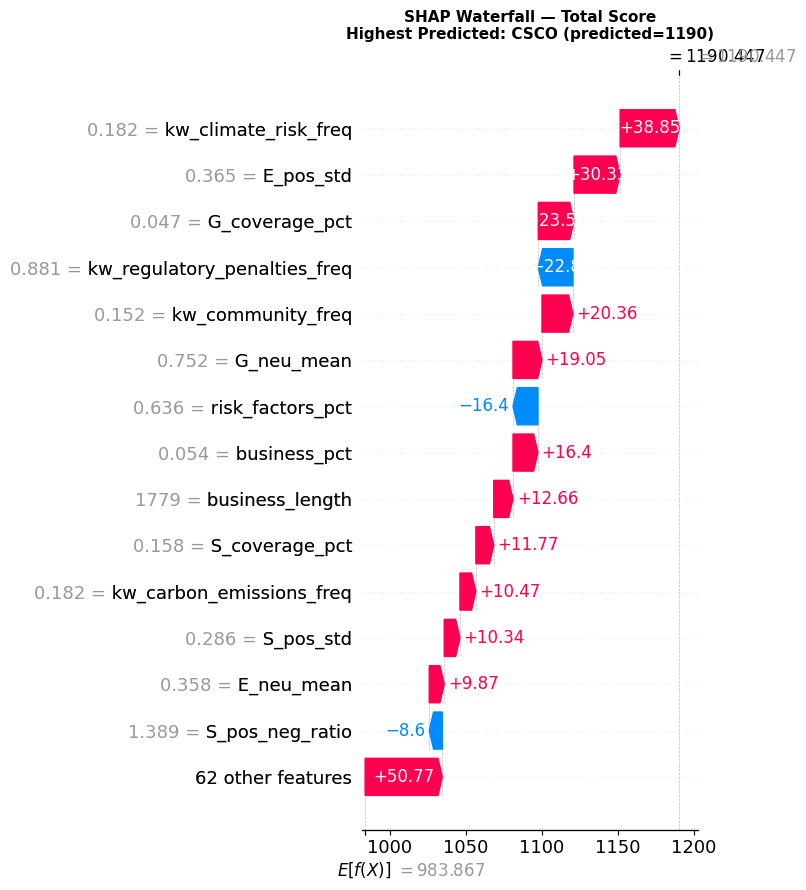

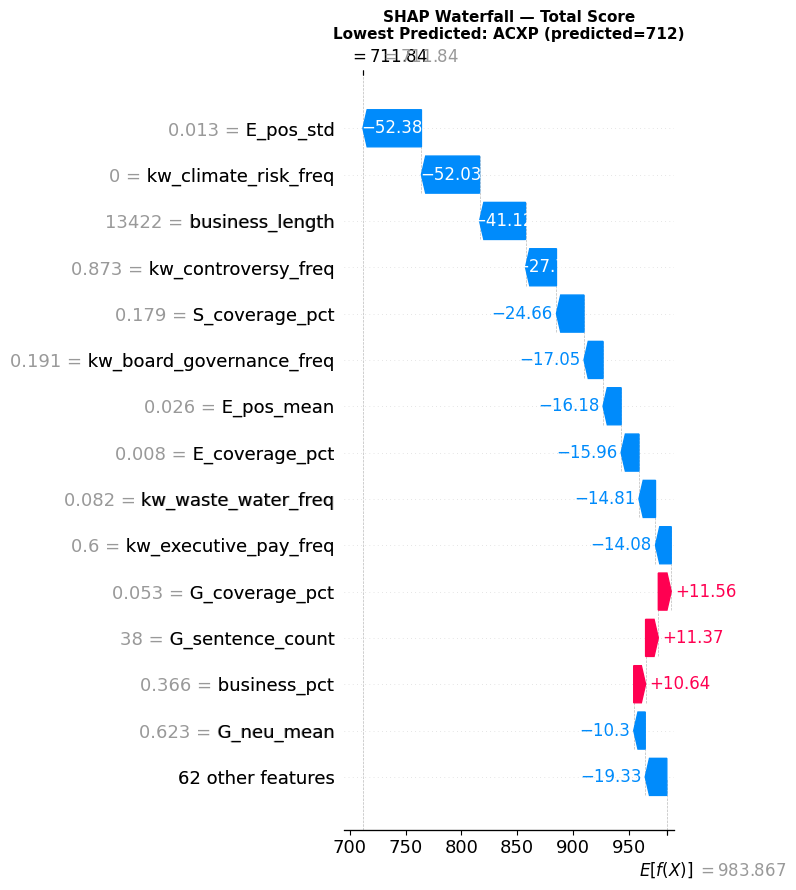

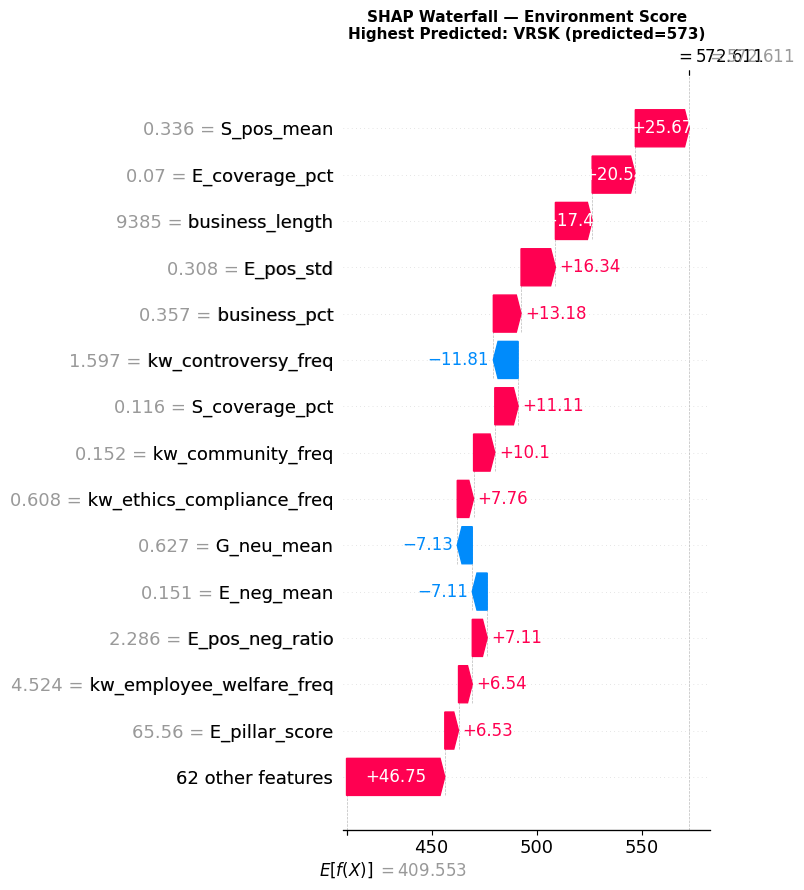

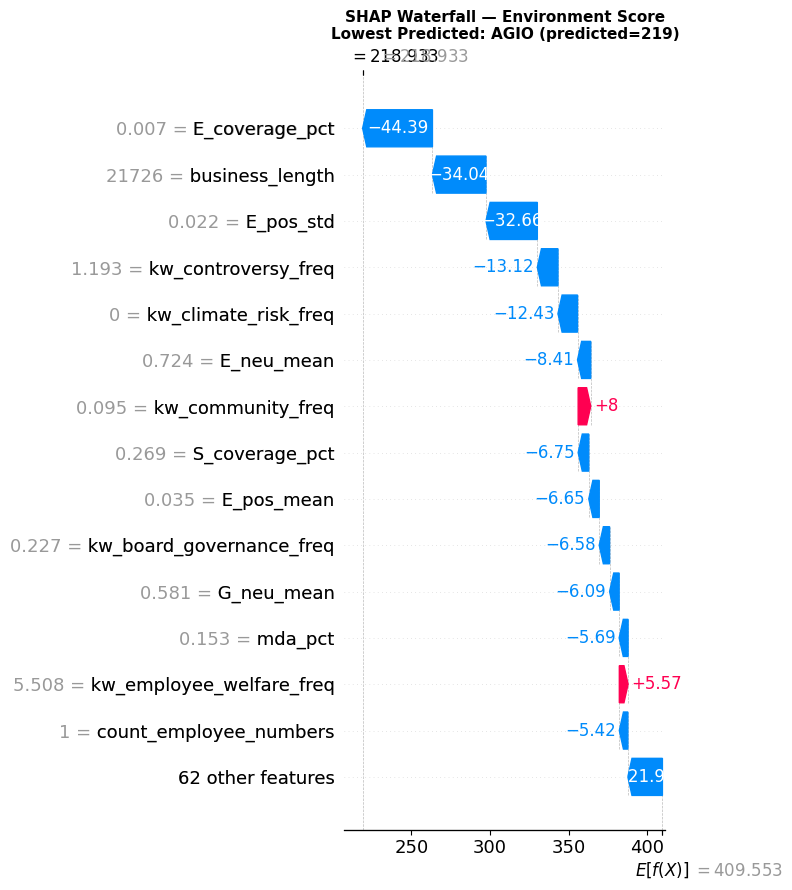

In [8]:
if HAS_SHAP and shap_values:
    for target in ['total_score', 'environment_score']:
        if target not in shap_values:
            continue

        X_te      = split_data[target]['X_te']
        explainer = explainers[target]
        sv        = shap_values[target]

        pred_scores = trained_models[target].predict(X_te)
        best_idx    = np.argmax(pred_scores)
        worst_idx   = np.argmin(pred_scores)

        for idx, label in [(best_idx, 'Highest Predicted'), (worst_idx, 'Lowest Predicted')]:
            plt.figure()
            shap.waterfall_plot(
                shap.Explanation(
                    values=sv[idx],
                    base_values=explainer.expected_value,
                    data=X_te.iloc[idx],
                    feature_names=feature_cols
                ),
                max_display=15,
                show=False
            )
            ticker = df.loc[X_te.index[idx], 'ticker'] if 'ticker' in df.columns else f'Company {idx}'
            plt.title(
                f'SHAP Waterfall — {target.replace("_score","").title()} Score\n'
                f'{label}: {ticker} (predicted={pred_scores[idx]:.0f})',
                fontsize=11, fontweight='bold'
            )
            plt.tight_layout()
            plt.savefig(
                OUTPUT_DIR + f'shap_waterfall_{target}_{label.replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight'
            )
            plt.show()

---
## Step 9 — SHAP Dependence Plots

Dependence plots show how a single feature's value affects its SHAP contribution,
revealing non-linear relationships and interaction effects.

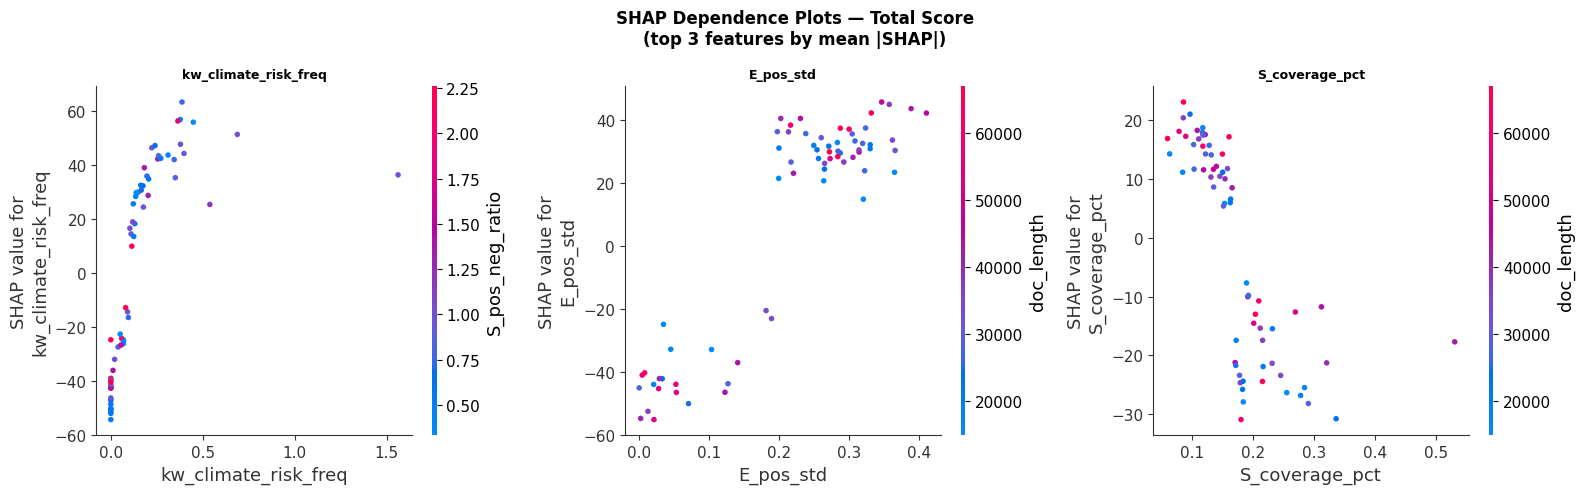

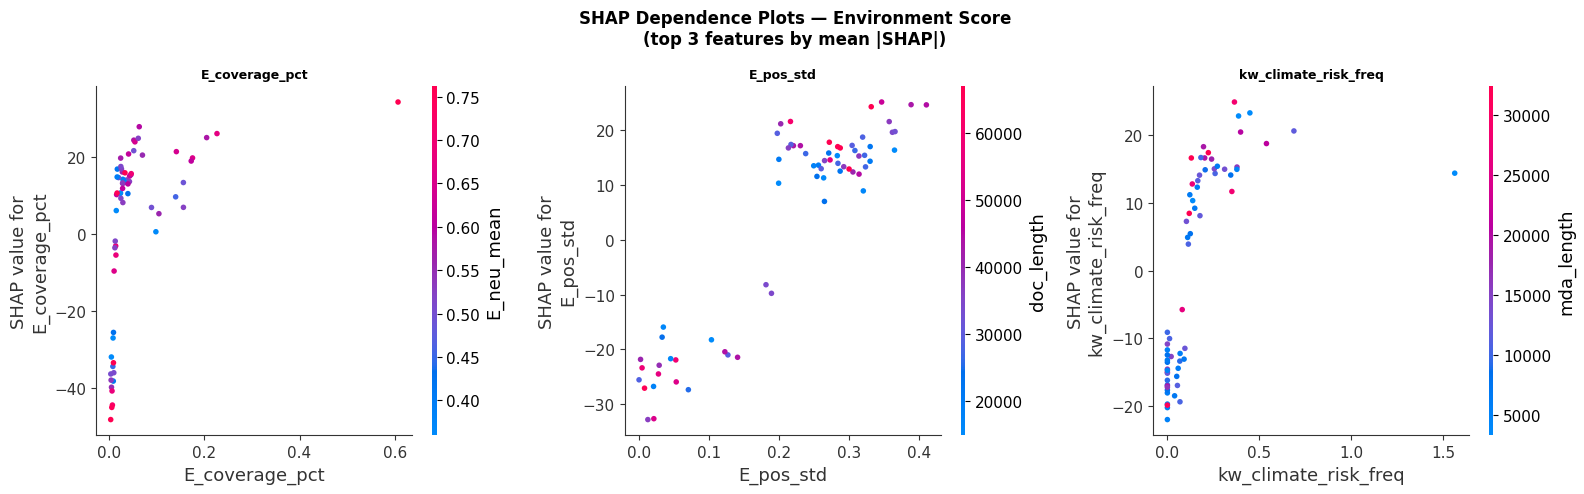

In [9]:
if HAS_SHAP and shap_values:
    for target in ['total_score', 'environment_score']:
        if target not in shap_values:
            continue

        sv   = shap_values[target]
        X_te = split_data[target]['X_te']

        mean_abs   = np.abs(sv).mean(axis=0)
        top3_idx   = np.argsort(mean_abs)[::-1][:3]
        top3_feats = [feature_cols[i] for i in top3_idx]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, feat in zip(axes, top3_feats):
            feat_idx = feature_cols.index(feat)
            shap.dependence_plot(
                feat_idx, sv, X_te,
                feature_names=feature_cols,
                ax=ax, show=False
            )
            ax.set_title(feat, fontsize=9, fontweight='bold')

        plt.suptitle(
            f'SHAP Dependence Plots — {target.replace("_score","").title()} Score\n'
            f'(top 3 features by mean |SHAP|)',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR + f'shap_dependence_{target}.png',
            dpi=150, bbox_inches='tight'
        )
        plt.show()

---
## Step 10 — Industry-Level SHAP Analysis

Compares mean SHAP contributions across industries to understand why
the model performs differently for different sectors.

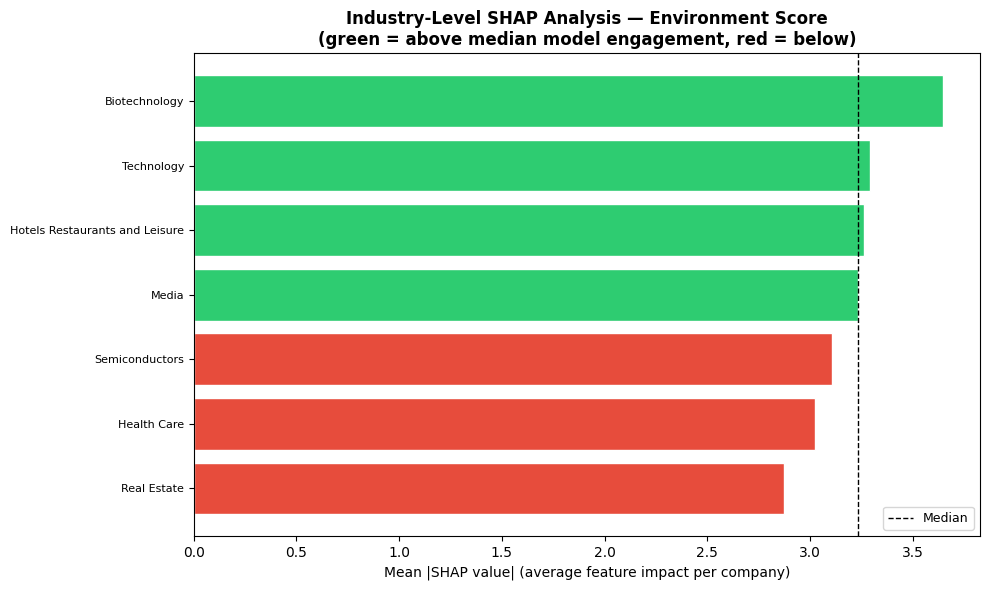

Mean |SHAP| by industry (environment score):
industry
Biotechnology                     3.6447
Technology                        3.2894
Hotels Restaurants and Leisure    3.2614
Media                             3.2311
Semiconductors                    3.1078
Health Care                       3.0227
Real Estate                       2.8714


In [10]:
if HAS_SHAP and shap_values and 'industry' in df.columns:
    target = 'environment_score'  
    if target not in shap_values:
        print(f"{target} not available.")
    else:
        sv   = shap_values[target]
        X_te = split_data[target]['X_te']

        # Map test indices back to industry
        industries = df.loc[X_te.index, 'industry'].values

        # Mean absolute SHAP per company → group by industry
        mean_abs_per_company = np.abs(sv).mean(axis=1)
        industry_shap = pd.Series(mean_abs_per_company, index=X_te.index)
        industry_df   = pd.DataFrame({
            'industry': industries,
            'mean_abs_shap': industry_shap.values
        })

        # Industries with at least 3 companies in test set
        ind_counts  = industry_df['industry'].value_counts()
        valid_inds  = ind_counts[ind_counts >= 3].index
        industry_df = industry_df[industry_df['industry'].isin(valid_inds)]

        ind_mean = (industry_df.groupby('industry')['mean_abs_shap']
                    .mean().sort_values(ascending=True))

        fig, ax = plt.subplots(figsize=(10, max(6, len(ind_mean) * 0.4)))
        colors  = ['#2ecc71' if v >= ind_mean.median() else '#e74c3c'
                   for v in ind_mean.values]
        ax.barh(ind_mean.index, ind_mean.values, color=colors, edgecolor='white')
        ax.axvline(ind_mean.median(), color='black', linestyle='--',
                   linewidth=1, label='Median')
        ax.set_xlabel('Mean |SHAP value| (average feature impact per company)')
        ax.set_title(
            'Industry-Level SHAP Analysis — Environment Score\n'
            '(green = above median model engagement, red = below)',
            fontsize=12, fontweight='bold'
        )
        ax.legend(fontsize=9)
        ax.tick_params(axis='y', labelsize=8)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR + 'shap_industry_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("Mean |SHAP| by industry (environment score):")
        print(ind_mean.sort_values(ascending=False).round(4).to_string())

---
## Step 11 — Summary

### M5.T4 — SHAP Explainability Findings

| Analysis | Output |
|---|---|
| Summary plots | Top 20 features by mean \|SHAP\| per pillar with direction |
| Bar plots | Global feature importance ranking per target |
| Cross-pillar heatmap | Which features matter universally vs. pillar-specific |
| Waterfall plots | Individual prediction explanations (highest/lowest predicted companies) |
| Dependence plots | Non-linear feature relationships for top 3 features |
| Industry analysis | Which industries the model engages with most strongly |

### Key Findings
- **Structured features** (log_total_assets, log_public_float) dominate environment score SHAP — company size is the strongest driver
- **Industry dummies** carry significant SHAP weight — sector membership is a stronger signal than text sentiment
- **FinBERT pillar scores** (E_pillar_score) rank highest among text features for environment
- **Governance** SHAP values are diffuse — no single feature dominates, consistent with poor R²
- **Social** benefits most from the combination of text + structured features